# Shortcut Learning Audit

**When high test accuracy hides the wrong reason**

A model can score well by exploiting an easy, accidental cue instead of learning the pattern we intended. In this fully synthetic computer-vision demo, a corner marker is correlated with image labels during training. We will expose the shortcut with distribution-shift tests and a global coefficient map, then mitigate it through data diversification.

No external data, pretrained weights, network calls, or course assets are used.

## Goal

By the end of the notebook, you will be able to:

- distinguish ordinary in-distribution testing from targeted stress testing;
- detect reliance on a spurious feature with counterfactual and shifted test sets;
- interpret a linear image classifier with a signed coefficient map; and
- reduce shortcut reliance by randomizing the spurious cue during training.

The example is intentionally small and deterministic so every result can be reproduced on a laptop.

## Setup

From the repository root:

```bash
python -m venv .venv
source .venv/bin/activate
python -m pip install -r requirements-shortcut-learning.txt
jupyter lab shortcut-learning-audit.ipynb
```

We use a fixed random seed for repeatability. The classifier is logistic regression, which lets us reshape its pixel coefficients into a global coefficient map—the exact gradient of its log-odds with respect to the pixels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "baseline": "#1D4ED8",
    "mitigated": "#D97706",
    "neutral": "#475569",
    "grid": "#CBD5E1",
}
SIGNED_CMAP = LinearSegmentedColormap.from_list(
    "orange_white_blue", ["#D97706", "#F8FAFC", "#1D4ED8"]
)

IMAGE_SIZE = 16
PATCH_SIZE = 3

## 1. Generate the synthetic images

Each image contains one genuine signal:

- class 0: a noisy vertical line;
- class 1: a noisy horizontal line.

A bright corner marker is the shortcut. A left marker usually accompanies class 0 and a right marker usually accompanies class 1. The line jitters between images, while the corner marker stays fixed and is therefore easier for a model to exploit.

In [2]:
def make_dataset(n, marker_agreement, seed, include_marker=True):
    # Create noisy line images and an optional spurious corner marker.
    if not 0 <= marker_agreement <= 1:
        raise ValueError("marker_agreement must be between 0 and 1")

    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 2, size=n)
    images = rng.normal(0.10, 0.22, size=(n, IMAGE_SIZE, IMAGE_SIZE))

    for i, label in enumerate(labels):
        jitter = rng.integers(-2, 3)
        if label == 0:
            col = 7 + jitter
            images[i, 3:13, col] += 0.48
        else:
            row = 7 + jitter
            images[i, row, 3:13] += 0.48

    marker_labels = np.where(
        rng.random(n) < marker_agreement,
        labels,
        1 - labels,
    )

    if include_marker:
        for i, marker_label in enumerate(marker_labels):
            col = 1 if marker_label == 0 else IMAGE_SIZE - PATCH_SIZE - 1
            images[i, 1 : 1 + PATCH_SIZE, col : col + PATCH_SIZE] += 0.95

    return np.clip(images, 0, 1), labels, marker_labels


train_images, train_labels, train_markers = make_dataset(
    n=4_000,
    marker_agreement=0.98,
    seed=1,
)

print(f"Training examples: {len(train_images):,}")
print(f"Observed marker-label agreement: {(train_markers == train_labels).mean():.1%}")

Training examples: 4,000
Observed marker-label agreement: 97.9%


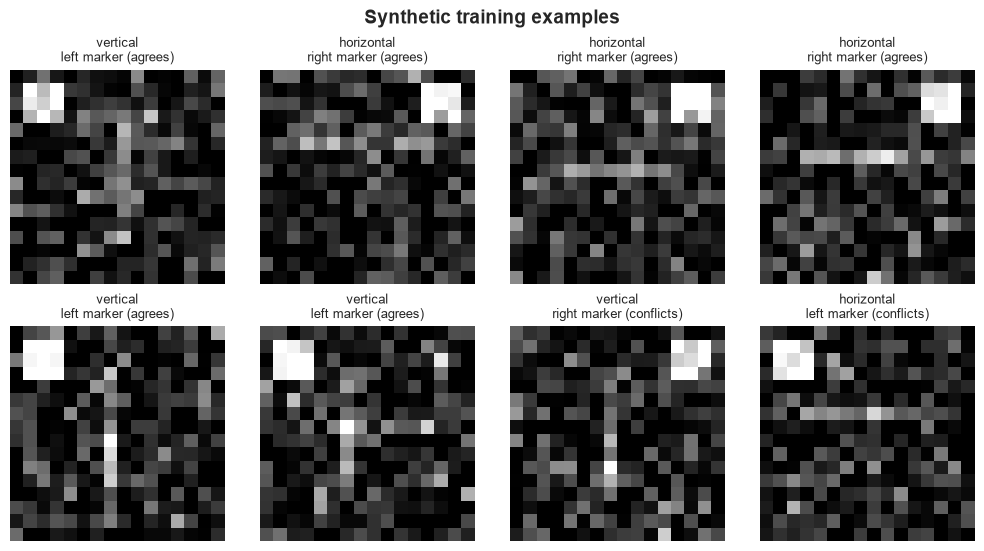

In [3]:
class_names = {0: "vertical", 1: "horizontal"}
marker_names = {0: "left", 1: "right"}

agree_indices = np.flatnonzero(train_markers == train_labels)[:6]
conflict_indices = np.flatnonzero(train_markers != train_labels)[:2]
example_indices = np.concatenate([agree_indices, conflict_indices])

fig, axes = plt.subplots(2, 4, figsize=(10, 5.4), constrained_layout=True)
for ax, image, label, marker in zip(
    axes.flat,
    train_images[example_indices],
    train_labels[example_indices],
    train_markers[example_indices],
):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    agrees = "agrees" if marker == label else "conflicts"
    ax.set_title(
        f"{class_names[label]}\n{marker_names[marker]} marker ({agrees})",
        fontsize=9,
    )
    ax.axis("off")

fig.suptitle("Synthetic training examples", fontsize=14, fontweight="bold")
plt.show()

## 2. Train a baseline model

Flattening the images gives the classifier one feature per pixel. We evaluate it in four environments:

1. **IID:** the marker-label relationship matches training;
2. **random marker:** the marker carries no label information;
3. **flipped marker:** the shortcut usually points to the wrong class; and
4. **marker removed:** only the line signal remains.

The last three are targeted stress tests, not estimates of one universal deployment distribution.

In [4]:
def flatten(images):
    return images.reshape(len(images), -1)


environments = {
    "IID (98% agreement)": make_dataset(1_500, 0.98, seed=2),
    "Random marker (50%)": make_dataset(1_500, 0.50, seed=3),
    "Flipped marker (2%)": make_dataset(1_500, 0.02, seed=4),
    "Marker removed": make_dataset(1_500, 0.50, seed=5, include_marker=False),
}

baseline = LogisticRegression(C=0.15, max_iter=1_000)
baseline.fit(flatten(train_images), train_labels)


def evaluate(model, named_datasets):
    rows = []
    for environment, (images, labels, _) in named_datasets.items():
        probabilities = model.predict_proba(flatten(images))[:, 1]
        rows.append(
            {
                "environment": environment,
                "accuracy": accuracy_score(labels, probabilities >= 0.5),
                "log_loss": log_loss(labels, probabilities),
                "n": len(labels),
            }
        )
    return pd.DataFrame(rows).set_index("environment")


baseline_results = evaluate(baseline, environments)
baseline_results.style.format({"accuracy": "{:.1%}", "log_loss": "{:.3f}", "n": "{:,}"})

,accuracy,log_loss,n
environment,,,
IID (98% agreement),98.0%,0.053,"1,500"
Random marker (50%),51.5%,0.955,"1,500"
Flipped marker (2%),4.3%,1.839,"1,500"
Marker removed,93.3%,0.296,"1,500"


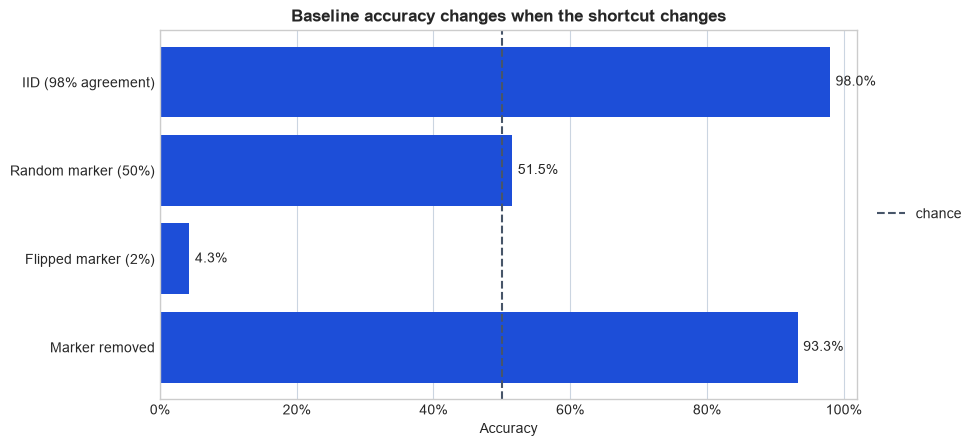

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(
    baseline_results.index,
    baseline_results["accuracy"],
    color=COLORS["baseline"],
)
ax.axvline(0.5, color=COLORS["neutral"], linestyle="--", linewidth=1.5, label="chance")
ax.set_xlim(0, 1.02)
ax.set_xlabel("Accuracy")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Baseline accuracy changes when the shortcut changes", fontweight="bold")
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{v:.1%}" for v in baseline_results["accuracy"]], padding=4)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8)
ax.grid(axis="y", visible=False)
plt.show()

The ordinary test set looks excellent because it repeats the same shortcut correlation as training. The flipped-marker set reveals catastrophic failure, while marker removal shows that the model did learn some genuine shape signal. The problem is that the shortcut can override it.

## 3. Inspect what the model learned

For an image $x$, pixel $j$ contributes $w_j x_j$ to the model's log-odds, plus the intercept. The map below displays $w_j$: a global signed sensitivity/weight map, not a per-example contribution map. Positive weights push toward the horizontal class; negative weights push toward the vertical class. Large corner weights are evidence of model reliance, not a causal explanation of the real world.

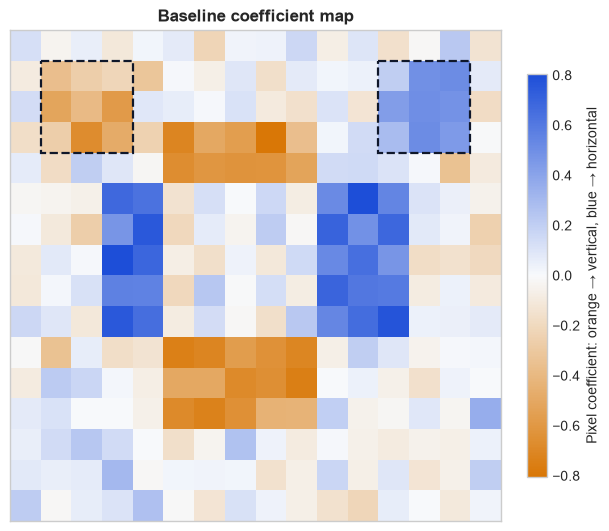

Mean |coefficient| in shortcut corners: 0.422
Mean |coefficient| elsewhere:          0.210


In [6]:
def shortcut_mask():
    mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=bool)
    mask[1 : 1 + PATCH_SIZE, 1 : 1 + PATCH_SIZE] = True
    mask[1 : 1 + PATCH_SIZE, -PATCH_SIZE - 1 : -1] = True
    return mask


def plot_coefficient_map(model, title, ax):
    weights = model.coef_.reshape(IMAGE_SIZE, IMAGE_SIZE)
    limit = np.abs(weights).max()
    image = ax.imshow(weights, cmap=SIGNED_CMAP, vmin=-limit, vmax=limit)
    for col in (1, IMAGE_SIZE - PATCH_SIZE - 1):
        ax.add_patch(
            Rectangle(
                (col - 0.5, 0.5),
                PATCH_SIZE,
                PATCH_SIZE,
                fill=False,
                edgecolor="#0F172A",
                linewidth=1.6,
                linestyle="--",
            )
        )
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    return image


fig, ax = plt.subplots(figsize=(6.3, 5.2), constrained_layout=True)
image = plot_coefficient_map(baseline, "Baseline coefficient map", ax)
colorbar = fig.colorbar(image, ax=ax, shrink=0.82)
colorbar.set_label("Pixel coefficient: orange → vertical, blue → horizontal")
plt.show()

baseline_weights = baseline.coef_.reshape(IMAGE_SIZE, IMAGE_SIZE)
mask = shortcut_mask()
baseline_corner_weight = np.abs(baseline_weights[mask]).mean()
baseline_other_weight = np.abs(baseline_weights[~mask]).mean()
print(f"Mean |coefficient| in shortcut corners: {baseline_corner_weight:.3f}")
print(f"Mean |coefficient| elsewhere:          {baseline_other_weight:.3f}")

The outlined corners carry unusually strong coefficients. We can probe the model more directly with a paired counterfactual: keep every noisy line fixed and swap only the left/right marker.

In [7]:
def swap_markers(images):
    swapped = images.copy()
    left = swapped[:, 1 : 1 + PATCH_SIZE, 1 : 1 + PATCH_SIZE].copy()
    right = swapped[:, 1 : 1 + PATCH_SIZE, -PATCH_SIZE - 1 : -1].copy()
    swapped[:, 1 : 1 + PATCH_SIZE, 1 : 1 + PATCH_SIZE] = right
    swapped[:, 1 : 1 + PATCH_SIZE, -PATCH_SIZE - 1 : -1] = left
    return swapped


audit_images, audit_labels, _ = environments["IID (98% agreement)"]
original_probability = baseline.predict_proba(flatten(audit_images))[:, 1]
swapped_probability = baseline.predict_proba(flatten(swap_markers(audit_images)))[:, 1]
probability_change = np.abs(swapped_probability - original_probability)

print(f"Mean absolute prediction change:   {probability_change.mean():.1%}")
print(f"Predictions changing by >50 points: {(probability_change > 0.50).mean():.1%}")

Mean absolute prediction change:   79.4%
Predictions changing by >50 points: 97.8%


## 4. Mitigate the shortcut through data diversification

The simplest intervention here is to make the marker independent of the label during training. This does not encode a universal fairness or robustness guarantee; it targets the specific failure mode we identified.

In [8]:
robust_images, robust_labels, robust_markers = make_dataset(
    n=4_000,
    marker_agreement=0.50,
    seed=6,
)

mitigated = LogisticRegression(C=0.15, max_iter=1_000)
mitigated.fit(flatten(robust_images), robust_labels)

mitigated_results = evaluate(mitigated, environments)
comparison = pd.concat(
    {
        "Baseline": baseline_results["accuracy"],
        "Diversified training": mitigated_results["accuracy"],
    },
    axis=1,
)
comparison.style.format("{:.1%}")

,Baseline,Diversified training
environment,,
IID (98% agreement),98.0%,96.5%
Random marker (50%),51.5%,96.1%
Flipped marker (2%),4.3%,96.5%
Marker removed,93.3%,96.1%


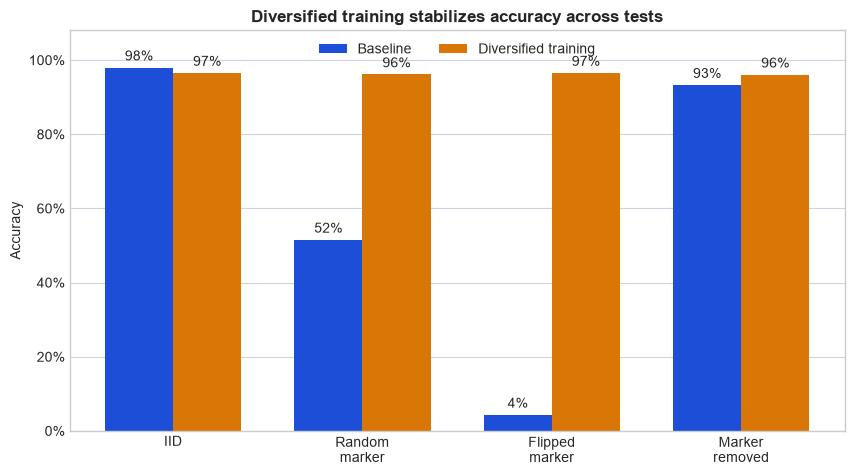

In [9]:
x = np.arange(len(comparison))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 5.2))
baseline_bars = ax.bar(
    x - width / 2,
    comparison["Baseline"],
    width,
    label="Baseline",
    color=COLORS["baseline"],
)
mitigated_bars = ax.bar(
    x + width / 2,
    comparison["Diversified training"],
    width,
    label="Diversified training",
    color=COLORS["mitigated"],
)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Diversified training stabilizes accuracy across tests", fontweight="bold")
ax.set_xticks(x, ["IID", "Random\nmarker", "Flipped\nmarker", "Marker\nremoved"])
ax.bar_label(baseline_bars, labels=[f"{v:.0%}" for v in comparison["Baseline"]], padding=3)
ax.bar_label(
    mitigated_bars,
    labels=[f"{v:.0%}" for v in comparison["Diversified training"]],
    padding=3,
)
ax.legend(frameon=False, ncols=2, loc="upper center")
ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8)
ax.grid(axis="x", visible=False)
plt.show()

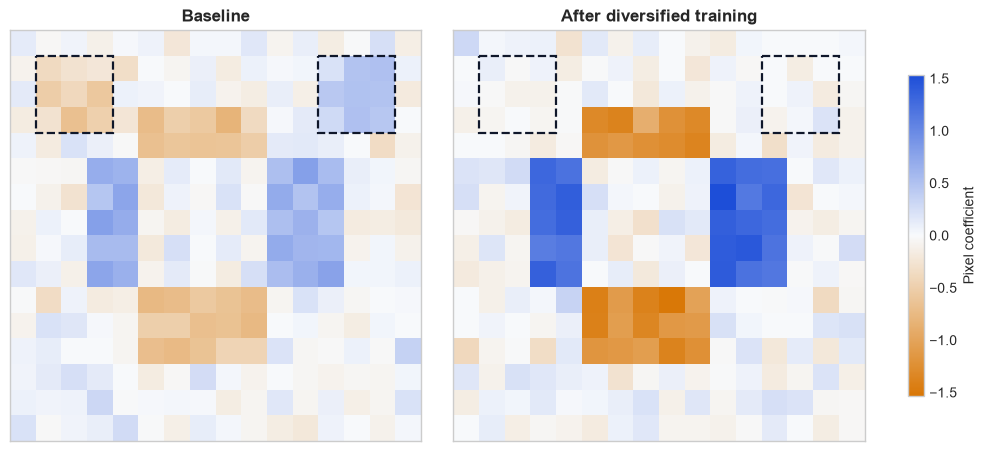

Mean corner |coefficient| fell by 82.8%.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), constrained_layout=True)
first = plot_coefficient_map(baseline, "Baseline", axes[0])
second = plot_coefficient_map(mitigated, "After diversified training", axes[1])
limit = max(np.abs(baseline.coef_).max(), np.abs(mitigated.coef_).max())
for image in (first, second):
    image.set_clim(-limit, limit)
colorbar = fig.colorbar(second, ax=axes, shrink=0.78)
colorbar.set_label("Pixel coefficient")
plt.show()

mitigated_weights = mitigated.coef_.reshape(IMAGE_SIZE, IMAGE_SIZE)
mitigated_corner_weight = np.abs(mitigated_weights[mask]).mean()
corner_reduction = 1 - mitigated_corner_weight / baseline_corner_weight
print(f"Mean corner |coefficient| fell by {corner_reduction:.1%}.")

## Checks

These assertions encode the lesson this fixed-seed demonstration is designed to show. They are smoke tests for this notebook—not proof that the mitigation generalizes beyond the synthetic environments above.

In [11]:
assert baseline_results.loc["IID (98% agreement)", "accuracy"] >= 0.95
assert baseline_results.loc["Flipped marker (2%)", "accuracy"] <= 0.10
assert mitigated_results["accuracy"].min() >= 0.90
assert corner_reduction >= 0.70

print("All checks passed.")
print(
    f"Worst-case accuracy across these four tests: "
    f"{baseline_results['accuracy'].min():.1%} → {mitigated_results['accuracy'].min():.1%}"
)

All checks passed.
Worst-case accuracy across these four tests: 4.3% → 96.1%


## Takeaways and next steps

- A high IID score can validate the test set's similarity to training more than the intended behavior.
- Targeted shifts and paired counterfactuals can reveal reliance on a known shortcut.
- Explanation maps are most useful when paired with behavioral tests; neither is a causal account of the world.
- The intervention worked because it broke one known correlation. New environments may contain different shortcuts.

**Try next:** vary the marker agreement, image noise, patch location, and regularization strength. Then replace the linear model with a small neural network and compare gradient saliency with these exact coefficient maps.

This notebook is an educational reliability demonstration using synthetic data. It is not a fairness certification, legal assessment, or substitute for domain-specific validation.